In [267]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [268]:
df = pd.read_csv("../data/processed/combined_clean.csv")

In [269]:
df.head()

,respondent_id,age_group,gender,college_year,monthly_budget_range,avg_monthly_budget,income_source,primary_upi_app,perceives_upi_risky,upi_usage_reason,...,cat_subscriptions,cat_gaming,cat_gadgets,cat_offline_cafe,cat_other,post_regret_action,hidden_purchase,regret_intensity,high_regret,regret_description
0,1000,22-25,Male,Ug,Rs6000+,18000.0,100% Parents Money,PhonePe,1,Comfort,...,0,1,0,0,0,Accept it or move on,0,3,0,Marrow course
1,1001,18-21,Male,Ug,Rs1000 - Rs3000,3500.0,100% Parents Money,PhonePe,1,Comfort,...,0,0,0,0,0,Accept it or move on,0,3,0,NaN
2,1002,18-21,Male,Ug,Rs1000 - Rs3000,2000.0,100% Parents Money,PhonePe,1,Comfort,...,0,0,0,0,0,Accept it or move on,1,1,0,NaN
3,1003,18-21,Male,Ug,Rs3000 - Rs6000,4500.0,100% Parents Money,Google Pay (GPay),1,Comfort,...,0,0,0,0,0,Accept it or move on,1,1,0,NaN
4,1004,Under 18,Female,Ug,Rs3000 - Rs6000,4500.0,100% Parents Money,PhonePe,1,Comfort,...,0,0,0,1,0,Accept it or move on,0,2,0,NaN


In [270]:
df.shape

(105, 44)

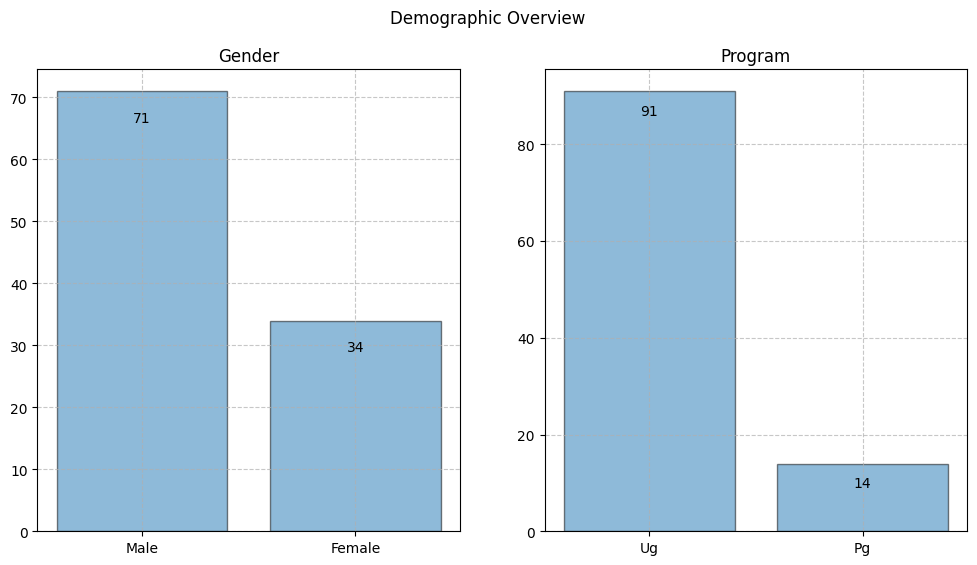

In [271]:
X_g_n = np.array(df["gender"].value_counts())
X_g_d = df["gender"].unique()
X_y_n = np.array(df["college_year"].value_counts())
X_y_d = df["college_year"].unique()
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.bar(X_g_d,X_g_n,alpha=0.5,edgecolor="black")
plt.text(0,X_g_n[0]-5,X_g_n[0],ha="center")
plt.text(1,X_g_n[1]-5,X_g_n[1],ha="center")
plt.title("Gender")
plt.xlabel("")
plt.ylabel("")
plt.grid(linestyle='--', alpha=0.7)
plt.subplot(1,2,2)
plt.bar(X_y_d,X_y_n,alpha=0.5,edgecolor="black")
plt.grid(linestyle='--', alpha=0.7)
plt.text(0,X_y_n[0]-5,X_y_n[0],ha="center")
plt.text(1,X_y_n[1]-5,X_y_n[1],ha="center")
plt.xlabel("")
plt.ylabel("")
plt.title("Program")
plt.suptitle("Demographic Overview")
plt.savefig("../reports/figures/plot_01_demographics.png", dpi=150, bbox_inches='tight')
plt.show()

In [272]:
df["monthly_budget_range"].value_counts()

monthly_budget_range
Rs1000 - Rs3000    50
Rs3000 - Rs6000    26
< Rs1000           17
Rs6000+            12
Name: count, dtype: int64

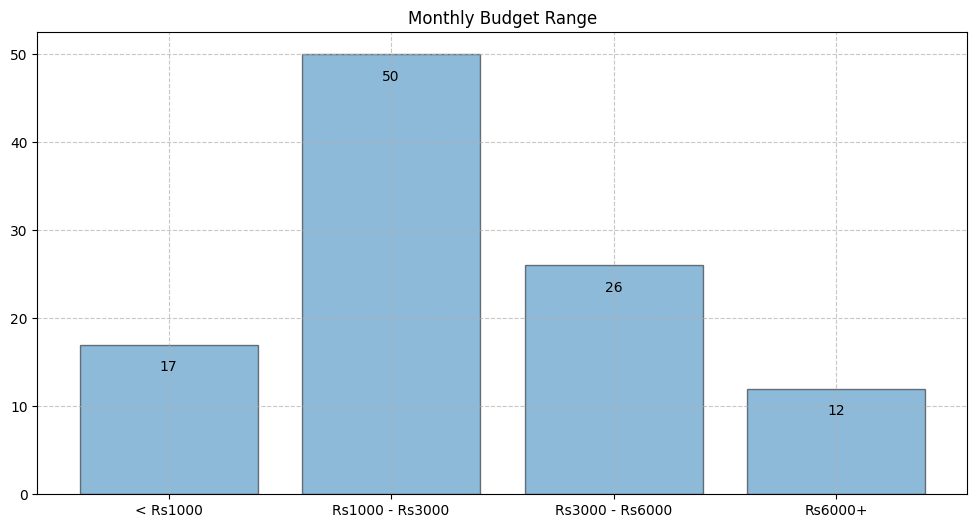

In [273]:
X_b_d = ['< Rs1000','Rs1000 - Rs3000','Rs3000 - Rs6000','Rs6000+']
X_b_n = [17,50,26,12]
plt.figure(figsize=(12,6))
plt.bar(X_b_d,X_b_n,alpha=0.5,edgecolor="black")
for i in range(len(X_b_n)):
    plt.text(i,X_b_n[i]-3,X_b_n[i],ha="center")
plt.title("Monthly Budget Range")
plt.xlabel("")
plt.ylabel("")
plt.grid(linestyle='--', alpha=0.7)
plt.savefig("../reports/figures/plot_02_budget_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [274]:
df["weekly_tx_range"].value_counts()

weekly_tx_range
4-7     40
8-15    29
15+     20
1-3     16
Name: count, dtype: int64

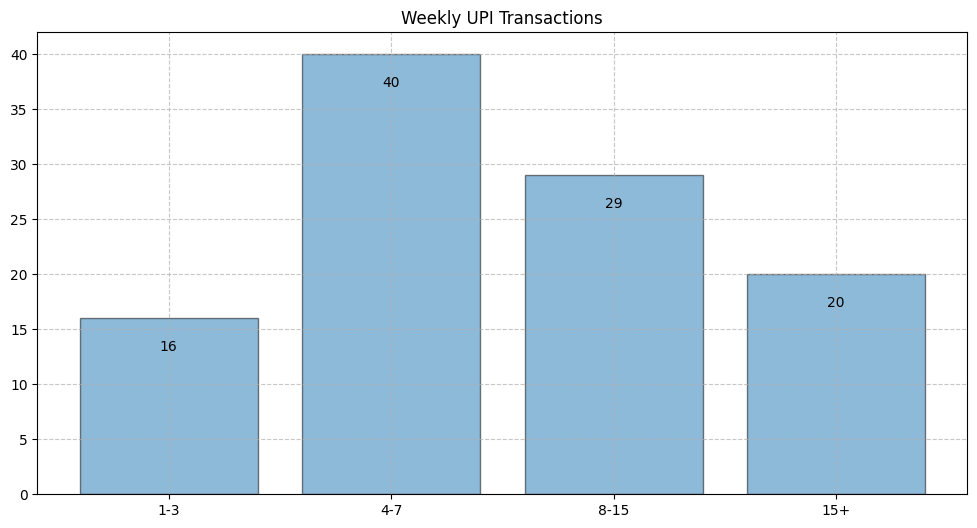

In [275]:
X_t_d = ['1-3','4-7','8-15','15+']
X_t_n = [16,40,29,20]
plt.figure(figsize=(12,6))
plt.bar(X_t_d,X_t_n,alpha=0.5,edgecolor="black")
for i in range(len(X_t_n)):
    plt.text(i,X_t_n[i]-3,X_t_n[i],ha="center")
plt.title("Weekly UPI Transactions")
plt.xlabel("")
plt.ylabel("")
plt.grid(linestyle='--', alpha=0.7)
plt.savefig("../reports/figures/plot_03_transaction_frequency.png", dpi=150, bbox_inches='tight')
plt.show()

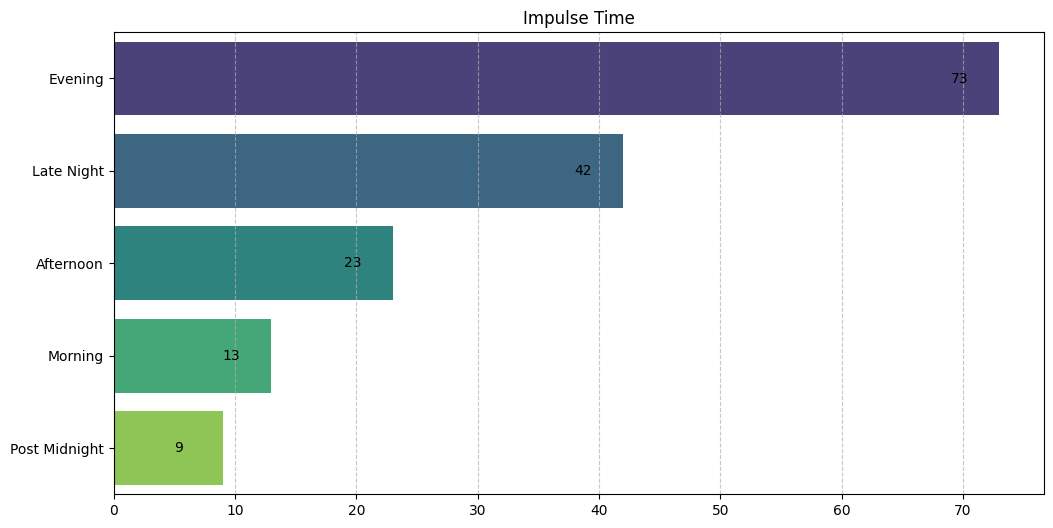

In [276]:
impuls_time = [
    'flag_morning', 'flag_afternoon', 'flag_evening',
    'flag_latenight', 'flag_postmidnight'
]
X = df[impuls_time].sum().sort_values(ascending=False).reset_index()
X.columns = ['time', 'count']
label_map = {
    'flag_morning': 'Morning',
    'flag_afternoon': 'Afternoon',
    'flag_evening': 'Evening',
    'flag_latenight': 'Late Night',
    'flag_postmidnight': 'Post Midnight'
}
X['time'] = X['time'].map(label_map)
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=X, x='count', y='time', palette='viridis')
for i, v in enumerate(X['count']):
    ax.text(v - 4, i, str(v), va='center')
plt.title("Impulse Time")
plt.xlabel("")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig("../reports/figures/plot_04_impulse_time.png", dpi=150, bbox_inches='tight')
plt.show()

In [277]:
df["pct_unplanned"].value_counts()

pct_unplanned
40-60%    39
20-40%    34
<20%      23
60-80%     5
80%+       4
Name: count, dtype: int64

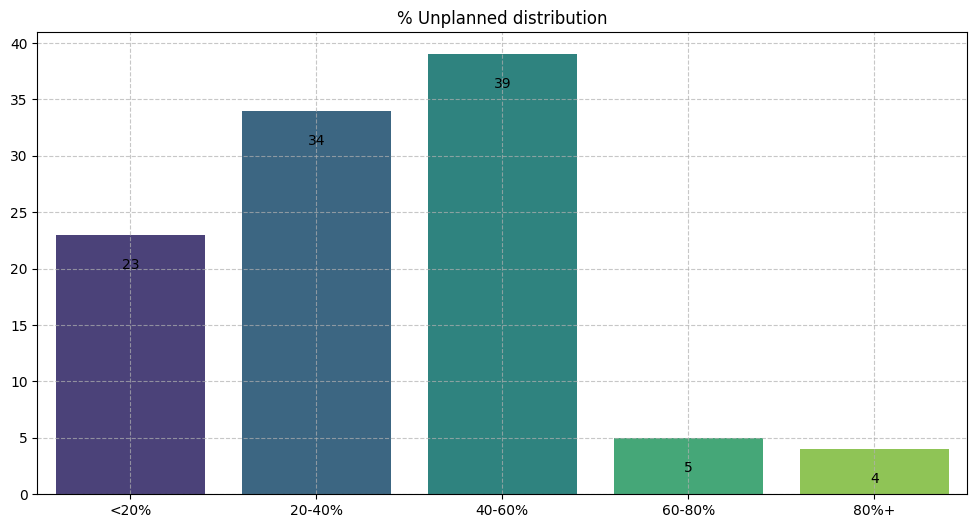

In [278]:
X_u_d = ['<20%','20-40%','40-60%','60-80%','80%+']
X_u_n = [23,34,39,5,4]
plt.figure(figsize=(12,6))
sns.countplot(x="pct_unplanned",data=df,palette='viridis',order=X_u_d)
for i in range(len(X_u_n)):
    plt.text(i,X_u_n[i]-3,X_u_n[i],ha="center")
plt.title("% Unplanned distribution")
plt.xlabel("")
plt.ylabel("")
plt.savefig("../reports/figures/plot_05_unplanned_distribution.png", dpi=150, bbox_inches='tight')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

In [279]:
df["regret_frequency"].value_counts()

regret_frequency
1    51
0    28
2    16
4     6
3     4
Name: count, dtype: int64

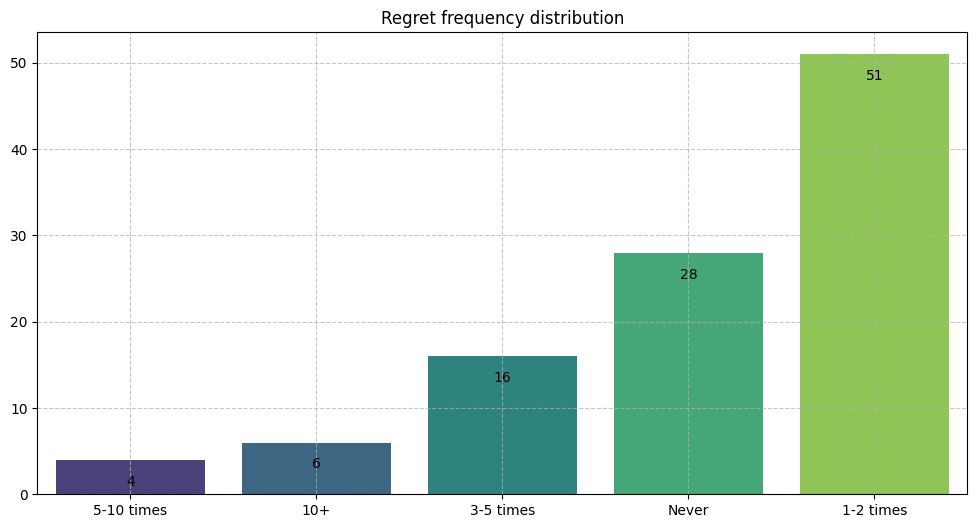

In [280]:
df["regret_frequency_c"] = df["regret_frequency"]
regret_map = {
    0:"Never",
    1:"1-2 times",
    2:"3-5 times",
    3:"5-10 times",
    4:"10+"
}
df["regret_frequency"] = df["regret_frequency"].map(regret_map)
X_b_n = np.sort(np.array(df["regret_frequency"].value_counts()))
plt.figure(figsize=(12,6))
sns.countplot(x="regret_frequency",data=df,palette='viridis',order=df['regret_frequency'].value_counts(ascending=True).index)
for i in range(len(X_b_n)):
    plt.text(i,X_b_n[i]-3,X_b_n[i],ha="center")
plt.title("Regret frequency distribution")
plt.xlabel("")
plt.ylabel("")
plt.grid(linestyle='--', alpha=0.7)
plt.savefig("../reports/figures/plot_06_regret_frequency.png", dpi=150, bbox_inches='tight')
plt.show()

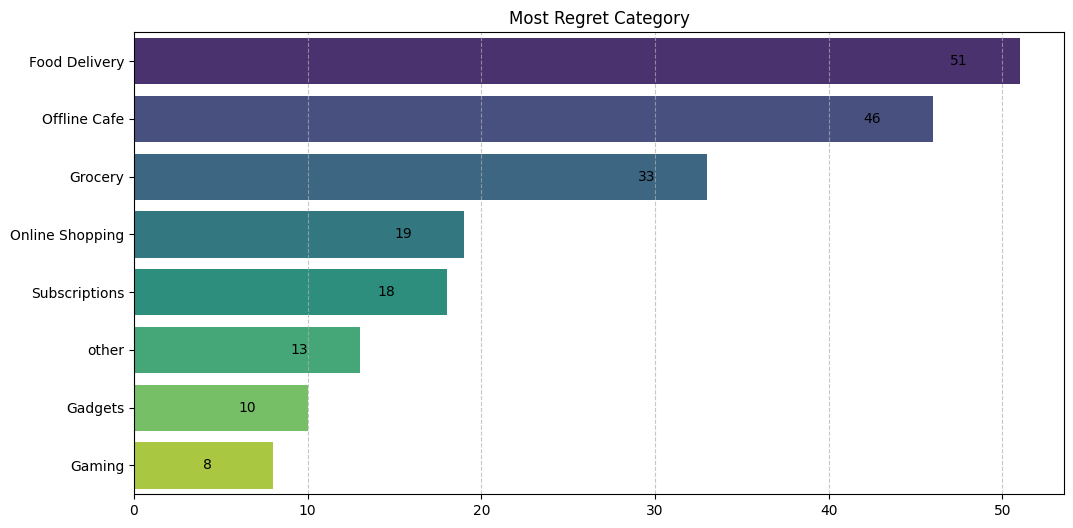

In [281]:
regret_cat = [
    'cat_food_delivery', 'cat_grocery', 'cat_online_shopping', 'cat_subscriptions', 'cat_gaming', 'cat_gadgets', 'cat_offline_cafe','cat_other'
]
X = df[regret_cat].sum().sort_values(ascending=False).reset_index()
X.columns = ['cat', 'count']
label_map = {
    'cat_food_delivery' : 'Food Delivery', 'cat_grocery' : 'Grocery', 'cat_online_shopping' : 'Online Shopping', 'cat_subscriptions' : 'Subscriptions', 'cat_gaming' : 'Gaming', 'cat_gadgets' : "Gadgets", 'cat_offline_cafe' : "Offline Cafe",'cat_other' : "other"
}
X['cat'] = X['cat'].map(label_map)
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=X, x='count', y='cat', palette='viridis')
for i, v in enumerate(X['count']):
    ax.text(v - 4, i, str(v), va='center')
plt.title("Most Regret Category")
plt.xlabel("")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig("../reports/figures/plot_07_regret_categories.png", dpi=150, bbox_inches='tight')
plt.show()

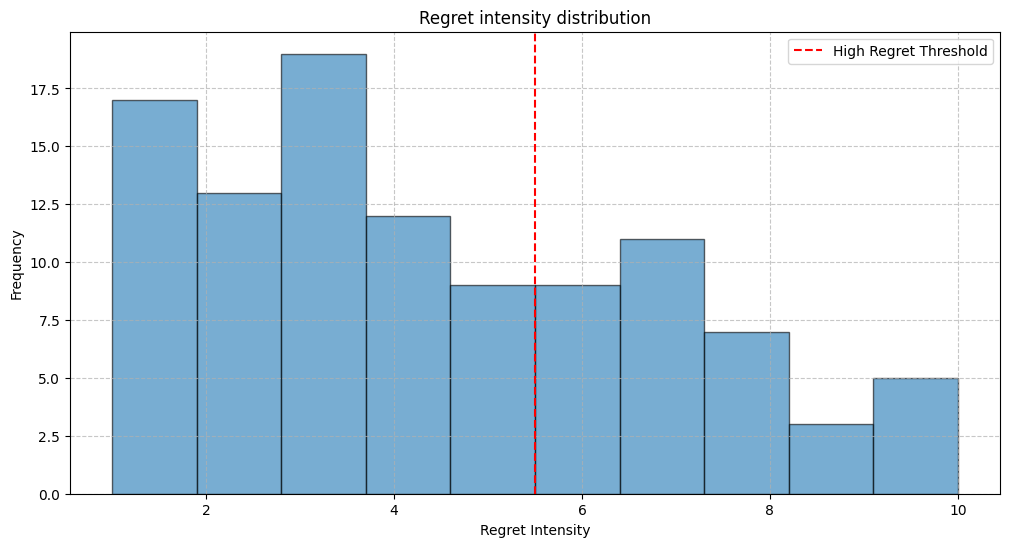

In [282]:
plt.figure(figsize=(12,6))
plt.hist(df["regret_intensity"],bins=10,align='mid',alpha=0.6,edgecolor="black")
plt.axvline(x=5.5, color='red', linestyle='--', label='High Regret Threshold')
plt.grid(linestyle='--', alpha=0.7)
plt.xlabel("Regret Intensity")
plt.title("Regret intensity distribution")
plt.ylabel("Frequency")
plt.savefig("../reports/figures/plot_08_regret_intensity.png", dpi=150, bbox_inches='tight')
plt.legend()
plt.show()

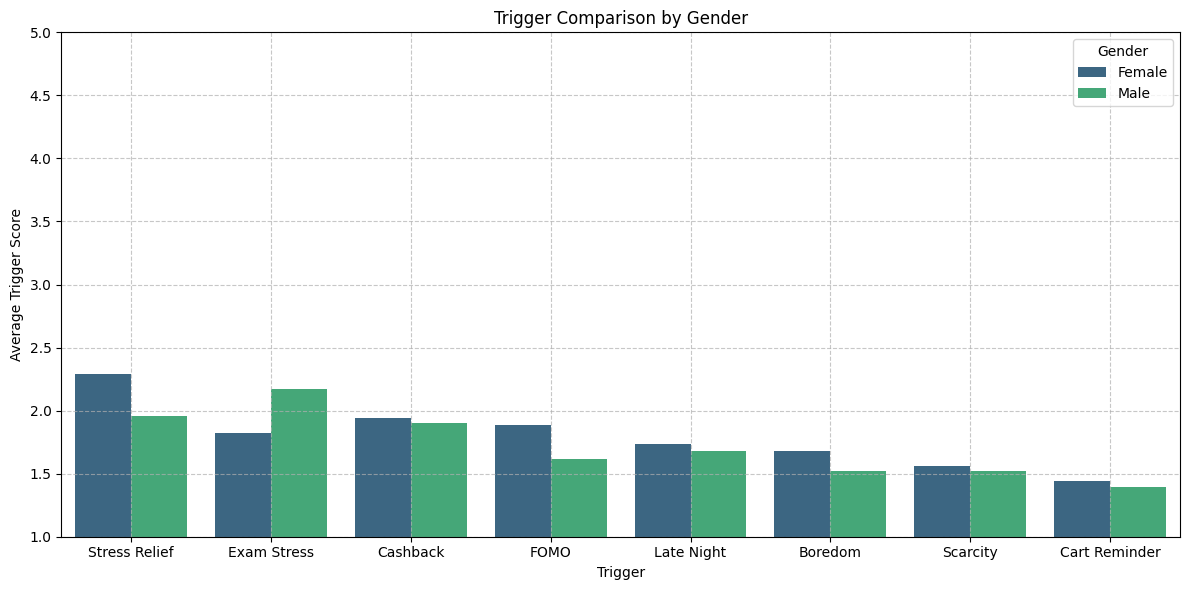

In [283]:
trigger_cols = [
    'trigger_boredom', 'trigger_fomo', 'trigger_latenight',
    'trigger_cashback', 'trigger_stress_relief',
    'trigger_scarcity_notif', 'trigger_cart_abandon',
    'trigger_exam_season'
]

df["Gender"] = df["gender"]
df_grouped = df.groupby('Gender')[trigger_cols].mean().reset_index()

df_melted = df_grouped.melt(
    id_vars='Gender',
    var_name='Trigger',
    value_name='mean'
)
label_map = {
    'trigger_boredom': 'Boredom',
    'trigger_fomo': 'FOMO',
    'trigger_latenight': 'Late Night',
    'trigger_cashback': 'Cashback',
    'trigger_stress_relief': 'Stress Relief',
    'trigger_scarcity_notif': 'Scarcity',
    'trigger_cart_abandon': 'Cart Reminder',
    'trigger_exam_season': 'Exam Stress'
}

df_melted['Trigger'] = df_melted['Trigger'].map(label_map)
order = df_melted.groupby('Trigger')['mean'].mean().sort_values(ascending=False).index
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_melted,
    x='Trigger',
    y='mean',
    hue='Gender',
    palette='viridis',
    order=order
)
plt.title("Trigger Comparison by Gender")
plt.xticks(fontsize=10)
plt.ylim(1, 5)
plt.ylabel("Average Trigger Score")
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("../reports/figures/plot_09_trigger_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

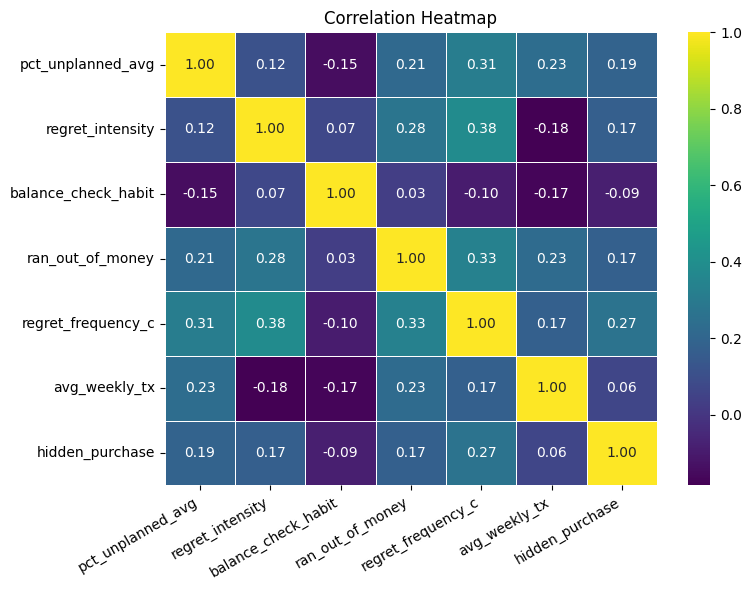

In [284]:
corr_cols = [
    'pct_unplanned_avg',
    'regret_intensity',
    'balance_check_habit',
    'ran_out_of_money',
    'regret_frequency_c',
    'avg_weekly_tx',
    'hidden_purchase'
]
corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/plot_10_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

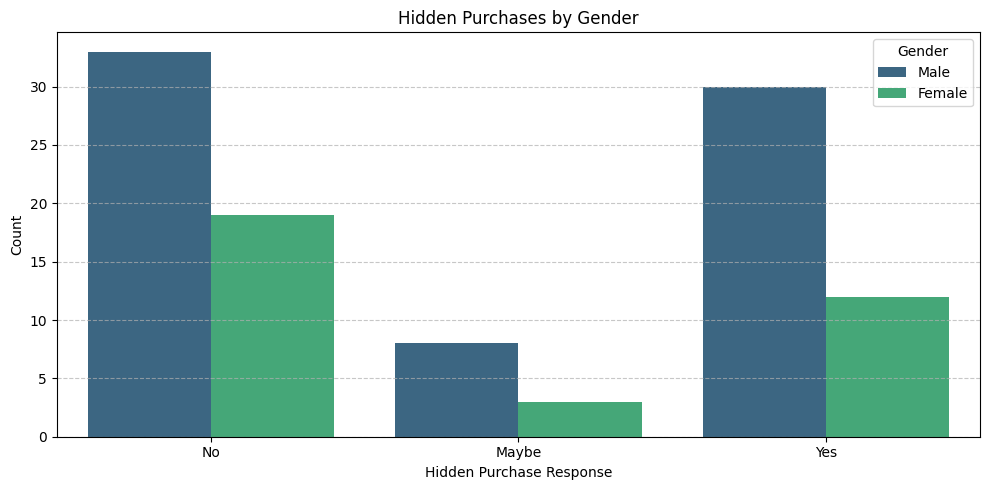

In [285]:
mapr = {
    0 : 'No',
    1 : 'Maybe',
    2 : 'Yes'
}
plt.figure(figsize=(10,5))
df['Hidden Purchase'] = df['hidden_purchase'].map(mapr)
df['Gender'] = df['gender']

sns.countplot(
    data=df,
    x='Hidden Purchase',
    hue='Gender',
    palette='viridis'
)

plt.title("Hidden Purchases by Gender")
plt.xlabel("Hidden Purchase Response")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("../reports/figures/plot_11_hidden_purchase_gender.png", dpi=150, bbox_inches='tight')
plt.show()

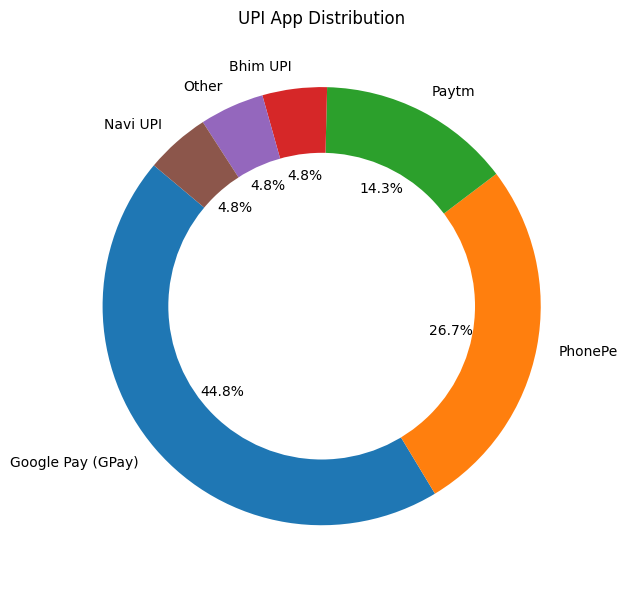

In [286]:
upi_counts = df['primary_upi_app'].value_counts()
threshold = 5
small_apps = upi_counts[upi_counts < threshold].index
df['upi_app_clean'] = df['primary_upi_app'].replace(small_apps, 'Other')
upi_counts_clean = df['upi_app_clean'].value_counts()
plt.figure(figsize=(12,6))
plt.pie(
    upi_counts_clean,
    labels=upi_counts_clean.index,
    autopct='%1.1f%%',
    startangle=140
)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("UPI App Distribution")
plt.tight_layout()
plt.savefig("../reports/figures/plot_12_upi_distribution.png", dpi=150, bbox_inches='tight')
plt.show()